In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import re
import io
from pathlib import Path
from core.normalizer import compute_wallmid3, compute_wallmid2, compute_wallmid1

In [6]:
#SIM DATA PROP 4
log_path=Path("/Users/alexoddsh/prosperity/backend/logs/53bc40ff-8808-4d7d-84b6-53a32cab4d8d_67226.log")
data = json.loads(log_path.read_text())
ai = data["activitiesLog"]
th = data["tradeHistory"]
ied = data["logs"]

prices = pd.read_csv(io.StringIO(ai), sep=";")
trades = pd.DataFrame(th)

prices["day"] = 1
trades["day"] = 1

#TUTORIAL DATA PROP 4
log_path2=Path("/Users/alexoddsh/prosperity/backend/logs/55375961-932b-4308-92cb-7efd894ebbc6.log")
text = log_path2.read_text()
ai2 = text.find("Activities log:\n")
ti2 = text.find("Trade History:\n")

if ai2 == -1 or ti2 == -1:
    raise ValueError("  [ERROR]: Could not find Activities log or Trade History ---")

prices_str = text[ai2 + len("Activities log:\n"):ti2].strip()
prices2 = pd.read_csv(io.StringIO(prices_str), sep=";")

time_to_day = dict(zip(prices2['timestamp'], prices2['day']))
trade_str = text[ti2 + len("Trade History:\n"):].strip()
trade_str = re.sub(r',\s*([}\]])', r'\1', trade_str)
trades2 = pd.DataFrame(json.loads(trade_str))
trades2['day'] = trades2['timestamp'].map(time_to_day)

#OLD DATA PROP 3
old_log_path=Path("/Users/alexoddsh/prosperity/backend/logs/bfd722f3-7c14-4e0f-abc5-b91e80150bd1.log")
text = old_log_path.read_text()
ai3 = text.find("Activities log:\n")
ti3 = text.find("Trade History:\n")

if ai3 == -1 or ti3 == -1:
    raise ValueError("  [ERROR]: Could not find Activities log or Trade History ---")

prices_str = text[ai3 + len("Activities log:\n"):ti3].strip()
prices3 = pd.read_csv(io.StringIO(prices_str), sep=";")

time_to_day = dict(zip(prices3['timestamp'], prices3['day']))
trade_str_1 = text[ti3 + len("Trade History:\n"):].strip()
trade_str_1 = re.sub(r',\s*([}\]])', r'\1', trade_str_1)
trades3 = pd.DataFrame(json.loads(trade_str_1))
trades3['day'] = trades3['timestamp'].map(time_to_day)



FileNotFoundError: [Errno 2] No such file or directory: '/Users/alexoddsh/prosperity/backend/logs/53bc40ff-8808-4d7d-84b6-53a32cab4d8d_67226.log'

count    2000.000000
mean       -0.015669
std         1.686302
min        -2.929688
25%        -1.464844
50%        -0.023438
75%         1.426758
max         2.958984
dtype: float64


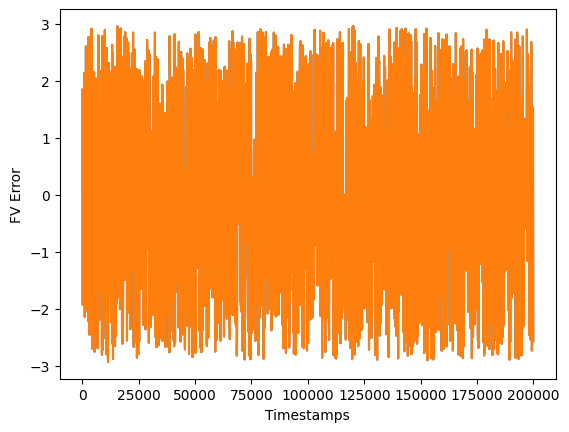

In [37]:
success1 = compute_wallmid3("TOMATOES", prices)
success2 = compute_wallmid2("TOMATOES", prices)
success3 = compute_wallmid1("TOMATOES", prices)

mask = prices["product"] == "TOMATOES"

if success1 and success2 and success3:
    entry_price = trades[trades["symbol"] == "TOMATOES"].iloc[0]["price"]
    trade_qty = trades[trades["symbol"] == "TOMATOES"].iloc[0]["quantity"]
    
    for i in prices[mask].index:
        mid_gap = prices.loc[i, "mid_price"] - entry_price
        wall_gap= prices.loc[i, "wallmid3"] - entry_price
        wall2_gap = prices.loc[i, "wallmid2"] - entry_price
        wall3_gap = prices.loc[i, "wallmid1"] - entry_price

        mid_pnl = mid_gap *trade_qty
        wall_pnl = wall_gap * trade_qty
        wall2_pnl = wall2_gap * trade_qty
        wall3_pnl = wall3_gap * trade_qty

        prices.loc[i, "mid_pnl"] = mid_pnl
        prices.loc[i, "wall_pnl"] = wall_pnl
        prices.loc[i, "wall2_pnl"] = wall2_pnl
        prices.loc[i, "wall3_pnl"] = wall3_pnl


timestamps = prices[prices["product"] == "TOMATOES"]["timestamp"]
pnls = prices[prices["product"] == "TOMATOES"]["profit_and_loss"]

error_mid = pnls - prices[prices["product"] == "TOMATOES"]["mid_pnl"]
error_wall = pnls - prices[prices["product"] == "TOMATOES"]["wall_pnl"]
error_wall2 = pnls - prices[prices["product"] == "TOMATOES"]["wall2_pnl"]
error_wall3 = pnls - prices[prices["product"] == "TOMATOES"]["wall3_pnl"]

error_mid.iloc[0] = 0
error_wall.iloc[0] = 0
error_wall2.iloc[0] = 0
error_wall3.iloc[0] = 0

spread = prices["ask_price_1"] - prices["bid_price_1"]

#print(error_wall.describe())
print(error_wall.describe())

plt.plot(timestamps, error_wall)
plt.plot(timestamps, error_wall2)
plt.ylabel("FV Error")
plt.xlabel("Timestamps")
plt.show()


Above we have "proven" that wallmid 2 is a reliable indicator for FV time T.

In [5]:
mask = prices["product"] == "TOMATOES"
timestamps = prices.loc[mask, "timestamp"]

for i in prices[mask].index:
    prices.loc[i, "ask"] = max(prices.loc[i, "ask_price_2"], prices.loc[i, "ask_price_3"])
    prices.loc[i, "bid"] = min(prices.loc[i, "bid_price_2"], prices.loc[i, "bid_price_3"]) 
    
    if pd.notna(prices.loc[i, "ask_price_3"]):
        prices.loc[i, "ask_vol"] = prices.loc[i, "ask_volume_3"] 
    else:
        prices.loc[i, "ask_vol"] = prices.loc[i, "ask_volume_2"]

    if pd.notna(prices.loc[i, "bid_price_3"]):
        prices.loc[i, "bid_vol"] = prices.loc[i, "bid_volume_3"] 
    else:
        prices.loc[i, "bid_vol"] = prices.loc[i, "bid_volume_2"]

prices = prices.copy()

spread = prices["ask"] - prices["bid"]
volspread = prices["ask_vol"] - prices["bid_vol"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].plot(timestamps, prices.loc[mask, "ask"])
axes[0].plot(timestamps, prices.loc[mask, "bid"])
axes[0].set_xlabel("Price")

axes[1].plot(timestamps, volspread[mask])
axes[1].set_xlabel("Volumes Spread")

plt.tight_layout()
plt.show()

print(spread.mean())

NameError: name 'prices' is not defined

This above is likely the "informed maker" that prev teams talked about, as we can see they quote symmetrically volume wise always and keep a constant spread of 16. Notice how following this makers mid would be exactly the same as our existing wallmid calculation. 

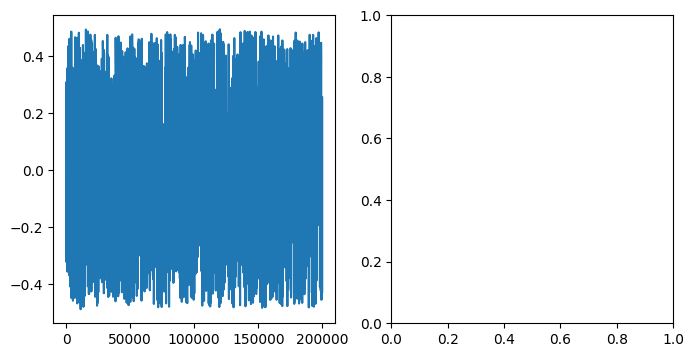

In [40]:
success1 = compute_wallmid3("TOMATOES", prices)
mask = prices["product"] == "TOMATOES"

if success1:
    entry_price = trades[trades["symbol"] == "TOMATOES"].iloc[0]["price"]
    trade_qty = trades[trades["symbol"] == "TOMATOES"].iloc[0]["quantity"]
    
    for i in prices[mask].index:
        wall_gap= prices.loc[i, "wallmid3"] - entry_price
        wall_pnl = wall_gap * trade_qty
        prices.loc[i, "wall_pnl"] = wall_pnl

timestamps = prices[prices["product"] == "TOMATOES"]["timestamp"]
pnls = prices[prices["product"] == "TOMATOES"]["profit_and_loss"]

error_wall = (pnls - prices[prices["product"] == "TOMATOES"]["wall_pnl"]) / trade_qty
error_wall.iloc[0] = 0

for i in error_wall.index:
    if abs(error_wall.loc[i]) > 2.9:
        print(prices.loc[i, "timestamp"])

fig, plots = plt.subplots(1, 2, figsize=(8, 4))

plots[0].plot(timestamps, error_wall)


As we can see the real price error between FV and wallmid3 is drifting between 0.5 and -0.5, my only idea to "close" this gap is to to check for correlation between different OB mechanics and the error to try and see how we can close the gap. 

In [41]:
#dependent
mask = (prices["product"] == "TOMATOES") & (prices["timestamp"] > 0) 

exact_fv = entry_price + (prices.loc[mask,"profit_and_loss"] / trade_qty)
wallmid = prices.loc[mask, "wallmid3"]
residual = exact_fv - wallmid

#independent vars
bid_vol_1 = prices.loc[mask, "bid_volume_1"]
bid_vol_2 = prices.loc[mask, "bid_volume_2"]
bid_vol_3 = prices.loc[mask, "bid_volume_3"]
ask_vol_1 = prices.loc[mask, "ask_volume_1"]
ask_vol_2 = prices.loc[mask, "ask_volume_2"]
ask_vol_3 = prices.loc[mask, "ask_volume_3"]
bid_vol_total = prices.loc[mask, "bid_volume_1"].fillna(0) + prices.loc[mask, "bid_volume_2"].fillna(0) + prices.loc[mask, "bid_volume_3"].fillna(0)
ask_vol_total = prices.loc[mask, "ask_volume_1"].fillna(0) + prices.loc[mask, "ask_volume_2"].fillna(0) + prices.loc[mask, "ask_volume_3"].fillna(0)
vol_imbalance = abs(ask_vol_total-bid_vol_total)

bid_price_1 = prices.loc[mask, "bid_price_1"]
ask_price_1 = prices.loc[mask, "ask_price_1"]
avg_wall_spread = ((wallmid - bid_price_1) + (ask_price_1-wallmid)) / 2
normal_mid = (bid_price_1 + ask_price_1) / 2
mid_offset = normal_mid - wallmid

INDEPENDENTS = {
    "bid_vol_1": bid_vol_1, 
    "bid_vol_2": bid_vol_2, 
    "bid_vol_3": bid_vol_3, 
    "ask_vol_1": ask_vol_1, 
    "ask_vol_2": ask_vol_2, 
    "ask_vol_3": ask_vol_3, 
    "bid_vol_tot": bid_vol_total, 
    "ask_vol_tot": ask_vol_total,
    "vol_imbalance": vol_imbalance, 
    "wall_spread": avg_wall_spread,
    "normal_mid": normal_mid,
    "mid_offset": mid_offset
}

for name, var in INDEPENDENTS.items():
    print(f"{name}: {residual.corr(var)}")

under = 0
mid = 0
over = 0

for i in mid_offset.index:
    if mid_offset[i] == -0.5:
        under += 1
    elif mid_offset[i] == 0.5:
        over += 1
    elif mid_offset[i] == 0.0:
        mid += 1

print(f"{under} -- {mid} -- {over}")

bid_vol_1: -0.03101346541160564
bid_vol_2: 0.005548287081711119
bid_vol_3: -0.1749841818195565
ask_vol_1: -0.024628826614227696
ask_vol_2: 0.00032637082755664895
ask_vol_3: -0.05326549192883741
bid_vol_tot: -0.026964486308339124
ask_vol_tot: -0.02070207395181788
vol_imbalance: -0.027801763896155966
wall_spread: 0.023515719879022692
normal_mid: 0.005098926527126989
mid_offset: 0.3588636060656005
477 -- 931 -- 466


We can see that the offset between the actual mid and wallmid is very evenly distributed 25% 50% 25% around [-0.5, 1, 0,5] why these discrete values? Because wallmid is a float and mid is a float and we always have 2 or 3 levels in discrete hops. But we do not always have the same amount of levels:

symmetric
- A2 = n+2
- A1 = n+1

- B1 = n-1
- B2 = n-2

-> mid = n -> wallmid = n

Here mid and wallmid are always the same. They only differ +/- 0.5 when 

asymmetric
- A3 = n+3
- A2 = n+2
- A1 = n+1

- B1 = n-1
- B2 = n-2

-> mid = n -> wallmid = n+0.5 

And the other way around for wallmid = n-0.5

As such we have 3 discrete groups of offset where the "real time noisy" mid is shifting from wallmid. My idea is that the IRL mid isnt FV ofc but captures the FV "change" more directly/better because it moves directly instead of wallmid where our "informed maker" might move only after the fact that other market participants have changed their view on price.

The idea is to not think of this maker as "informed" in that sense, he is simply a good proxy for FV since his quotes dont
oscillate up and down between t and t+1. Aka his levels only move when price is meaninfully shifting but IS he shifting price or more LIKELY is FV shifting and then he follows? Then this "noisy" trade at t+1 will temporarily tell us a bit more about FV than or not more per say but in which direction wallmid (aka the maker) is "lagging". 

The key here could be to section our 3 discrete groups and say for example: "IF mid offset = 0.5" -> residual between exact_fv and wallmid is in the 0-0.5 group. (remember we have already showed above that the error between wallmid and FV drifts between -0.5 and 0.5). 

That means that currently our best guess for FV in our bot is 0 (the mean of the error aka wallmid). But with the above we could perhaps say:
- mid_offset = -0.5 -> residual is in [-0.5, 0]
- mid_offset = 0.0 -> residual is [0] or also [-0.5, 0.5]??
- mid_offset = 0.5 -> residual is [0, 0.5] 

See the idea? If we could say this then our wallmid guess of FV isnt longer between [-0,5 -> 0.5] error it could be mid of [-0,5, 0] -> -0.25 or [0, 0,5] -> 0.25

In [42]:
under = []
middle = []
over = []

for res, off in zip(residual, mid_offset):
    if off == -0.5:
        under.append(res)
    if off == 0.0:
        middle.append(res)
    if off == 0.5:
        over.append(res)

print(sum(under) / len(under))
print(sum(middle) / len(middle))
print(sum(over) / len(over))

-0.3657673556516359
0.000481812790909418
0.3680522956902744


Solid? we have "confirmed" I think? AND LOOK at that 0.000 mean in group middle. I was correct above I think? If mid is a bit under wallmid then our error between wallmid and the FV is also negative and vice versa, we get:

- Mid > Wallmid -> we are ~0.37 OVER the actual FV
- Mid = Wallmid -> we are at the actual FV
- Mid < Wallmid 


[-0.5, -0,25] [-0.25, 0.25] [0.25, 0.5]

-0.5 ----- 0.0 ------- 0.5
25%        50%.       25%
/////XXXXXXXXXXXXXX/////////

wallmid = 100
FV 100.37

99
100


count    999.000000
mean       0.023424
std        0.919086
min       -1.900568
25%       -0.299716
50%        0.000000
75%        0.299716
max        7.099432
dtype: float64
count    996.000000
mean       0.223294
std        0.395757
min       -1.100568
25%       -0.000284
50%        0.200284
75%        0.400568
max        2.100568
dtype: float64


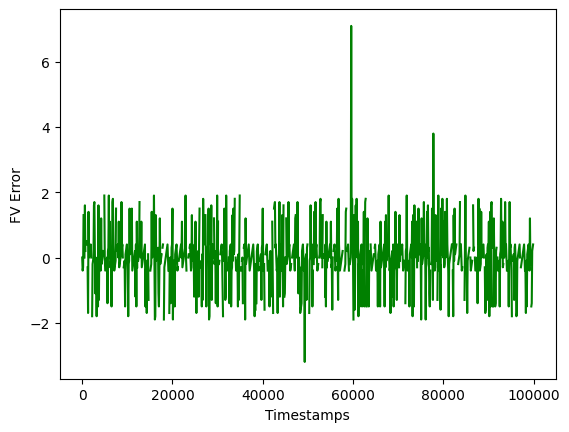

In [ ]:
success = compute_wallmid3(IPR, sim_df_ipr)
success = compute_wallmid_ma(IPR, sim_df_ipr)
success = compute_wallmid1(IPR, sim_df_ipr)
success = compute_wallmid2(IPR, sim_df_ipr)

if success:
    entry_price = sim_tf_ipr.iloc[0]["price"]
    trade_qty = sim_tf_ipr.iloc[0]["quantity"]
        
    for i in sim_df_ipr.index:
        mid_gap = sim_df_ipr.loc[i, "mid_price"] - entry_price
        wall1_gap = sim_df_ipr.loc[i, "wallmid1"] - entry_price
        wall2_gap = sim_df_ipr.loc[i, "wallmid2"] - entry_price
        wall3_gap = sim_df_ipr.loc[i, "wallmid3"] - entry_price
        wallma_gap = sim_df_ipr.loc[i, "wallmidsma"] - entry_price
        
        mid_pnl = mid_gap *trade_qty
        wall1_pnl = wall1_gap * trade_qty
        wall2_pnl = wall2_gap * trade_qty
        wall3_pnl = wall3_gap * trade_qty
        wallma_pnl = wallma_gap * trade_qty

        sim_df_ipr.loc[i, "mid_pnl"] = mid_pnl
        sim_df_ipr.loc[i, "wall1_pnl"] = wall1_pnl
        sim_df_ipr.loc[i, "wall2_pnl"] = wall2_pnl
        sim_df_ipr.loc[i, "wall3_pnl"] = wall3_pnl
        sim_df_ipr.loc[i, "wallma_pnl"] = wallma_pnl

    timestamps = sim_df_ipr["timestamp"]
    pnls = sim_df_ipr["profit_and_loss"]

    error_mid = (pnls - sim_df_ipr["mid_pnl"]) / trade_qty
    error_wall1 = (pnls - sim_df_ipr["wall1_pnl"]) / trade_qty
    error_wall2 = (pnls - sim_df_ipr["wall2_pnl"]) / trade_qty
    error_wall3 = (pnls - sim_df_ipr["wall3_pnl"]) / trade_qty
    error_wallma = (pnls - sim_df_ipr["wallma_pnl"]) / trade_qty 

    error_mid.iloc[0] = 0
    error_wall1.iloc[0] = 0
    error_wall2.iloc[0] = 0
    error_wall3.iloc[0] = 0
    error_wallma.iloc[0] = 0

    spread = sim_df_ipr["ask_price_1"] - sim_df_ipr["bid_price_1"]

    #plt.plot(timestamps, error_mid)
    #plt.plot(timestamps, error_wall1, color='red')
    plt.plot(timestamps, error_wall2, color='green')
    #plt.plot(timestamps, error_wall3, color='purple')
    #plt.plot(timestamps, error_wallma, color='pink')
    
    plt.ylabel("FV Error")
    plt.xlabel("Timestamps")

    plt.show()

else:
    print("fuck")

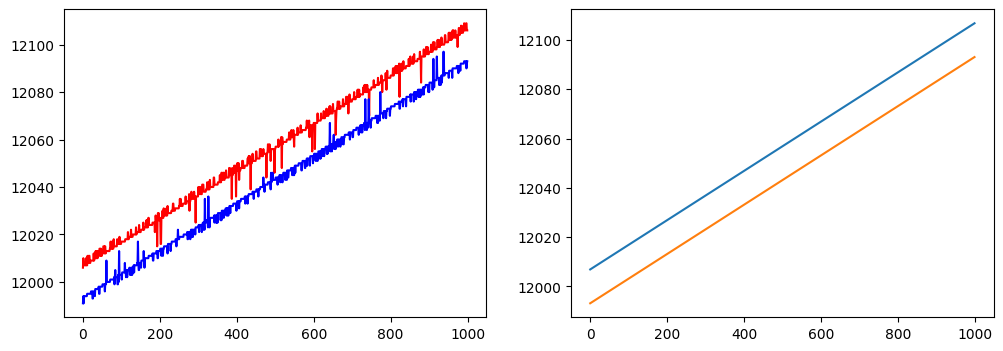

Intercept Ask: 12006.876025527785
Intercept Bid: 11993.144067190733
Slope Ask: 0.09997385859412278
Slope Bid: 0.09999835107835221


In [112]:
timestamps = sim_df_ipr["timestamp"].to_numpy() / 100
ask1 = sim_df_ipr["ask_price_1"]
bid1 = sim_df_ipr["bid_price_1"]

#ask regression
X = timestamps
X = np.column_stack([np.ones(len(X)), X])

beta_a = np.linalg.lstsq(X, ask1, rcond=None)[0]
beta_b = np.linalg.lstsq(X, bid1, rcond=None)[0]
y_a = beta_a[0] + beta_a[1] * timestamps
y_b = beta_b[0] + beta_b[1] * timestamps

sim_df_ipr["y_a"] = y_a
sim_df_ipr["y_b"] = y_b
sim_df_ipr["regwall"] = sim_df_ipr["y_a"] - sim_df_ipr["y_b"]

#figs
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(timestamps, ask1, color='red')
ax[0].plot(timestamps, bid1, color='blue')

ax[1].plot(timestamps, y_a)
ax[1].plot(timestamps, y_b)

plt.show()

print(f"Intercept Ask: {beta_a[0]}")
print(f"Intercept Bid: {beta_b[0]}")
print(f"Slope Ask: {beta_a[1]}")
print(f"Slope Bid: {beta_b[1]}")

count    999.000000
mean       0.053454
std        2.464288
min       -9.700284
25%       -0.400568
50%        0.000000
75%        0.400568
max       10.000000
dtype: float64


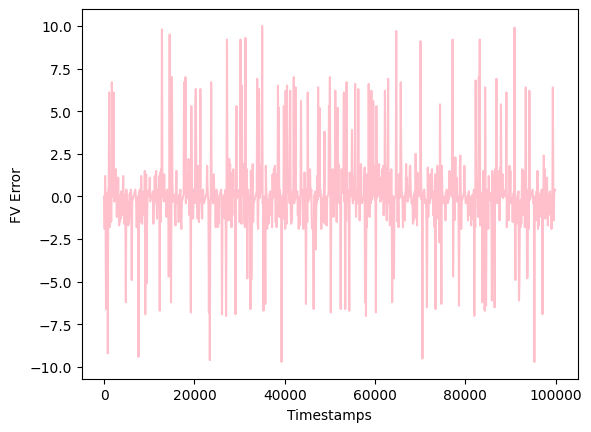

In [115]:
#Potential OP strategy

entry_price = sim_tf_ipr.iloc[0]["price"]
trade_qty = sim_tf_ipr.iloc[0]["quantity"]
    
for i in sim_df_ipr.index:
    regwall_gap = sim_df_ipr.loc[i, "regwall"] - entry_price
    regwall_pnl = regwall_gap *trade_qty

    sim_df_ipr.loc[i, "regwall_pnl"] = regwall_pnl
    
timestamps = sim_df_ipr["timestamp"]
pnls = sim_df_ipr["profit_and_loss"]

error_regwall = (pnls - sim_df_ipr["mid_pnl"]) / trade_qty
error_regwall.iloc[0] = 0

print(error_regwall.describe())

plt.plot(timestamps, error_regwall, color='pink')
plt.ylabel("FV Error")
plt.xlabel("Timestamps")
plt.show()
